In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ephys.src.utils.utils_IO import fetch_good_units, fetch_session_events
from ephys.src.utils.utils_analysis import (
    compute_population_peth,
    compute_unit_selectivity,
)

%matplotlib widget

/Users/gabriel/lib/ephys/.venv/lib/python3.11/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-03-06 13:22:33,631][INFO]: DataJoint 0.14.9 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [2]:
subject = "GRB058"
session = "20260224_152424"

st_per_unit = fetch_good_units(subject, session)
align_ev = fetch_session_events(subject, session)

unit_ids = list(st_per_unit.keys())
print(
    f"Loaded {len(unit_ids)} units, {len(align_ev['first_stim_ev'])} first-stim events"
)

Loaded 144 units, 219 first-stim events


In [3]:
# Compute population PETH aligned to first stimulus onset
peth, bin_edges, bin_centers = compute_population_peth(
    spike_times_per_unit=list(st_per_unit.values()),
    alignment_times=align_ev["first_stim_ev"],
    pre_seconds=0.1,
    post_seconds=0.15,
    binwidth_ms=10,
    t_rise=0.001,
    t_decay=0.025,
)
print(f"PETH shape: {peth.shape}  (units, trials, timebins)")

PETH shape: (144, 219, 23)  (units, trials, timebins)


In [7]:
# Baseline vs response selectivity test
results_df, masks = compute_unit_selectivity(
    peth,
    bin_edges,
    unit_ids=unit_ids,
    base_window=(-0.04, 0.0),
    resp_window=(0.06, 0.10),
    test="wilcoxon",
    alpha=0.05,
)

n_units = peth.shape[0]
print(
    f"Selective: {masks['selective'].sum()}/{n_units} "
    f"({masks['excited'].sum()} excited, {masks['suppressed'].sum()} suppressed)"
)
results_df.head(10)

Selective: 91/144 (39 excited, 52 suppressed)


,unit,mean_base,mean_resp,delta,cohen_d,si,p,q,excited,suppressed,selective
0,0,2.545514,3.036473,0.490960,0.057567,0.087954,6.740299e-01,7.409183e-01,False,False,False
1,1,6.711732,14.687743,7.976011,0.418723,0.372720,1.294787e-08,6.214978e-08,True,False,True
2,15,5.396364,1.119435,-4.276930,-0.404880,-0.656394,1.242321e-08,6.168764e-08,False,True,True
3,14,12.013541,4.943667,-7.069874,-0.354693,-0.416924,8.666199e-07,3.199827e-06,False,True,True
4,12,4.290453,7.959229,3.668776,0.289828,0.299500,1.259551e-05,3.778652e-05,True,False,True
5,346,2.627533,39.771950,37.144417,1.503596,0.876058,3.422762e-35,4.928777e-33,True,False,True
6,154,20.943935,9.318382,-11.625553,-0.692235,-0.384159,2.791046e-18,3.653733e-17,False,True,True
7,8,0.591277,0.233833,-0.357443,-0.101407,-0.433207,1.912673e-01,2.459151e-01,False,False,False
8,148,0.569233,0.225335,-0.343898,-0.121062,-0.432811,1.002696e-01,1.401827e-01,False,False,False
9,343,0.295016,0.048917,-0.246098,-0.117512,-0.715541,7.473550e-02,1.076191e-01,False,False,False


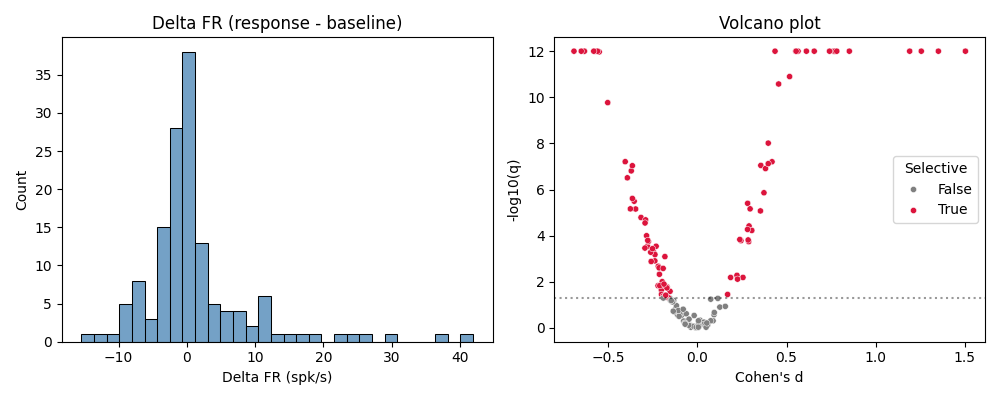

In [8]:
# Volcano plot: effect size vs significance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=results_df, x="delta", bins=31, ax=axes[0], color="steelblue")
axes[0].set(
    title="Delta FR (response - baseline)", xlabel="Delta FR (spk/s)", ylabel="Count"
)

sns.scatterplot(
    data=results_df,
    x="cohen_d",
    y=-np.log10(np.clip(results_df["q"], 1e-12, 1.0)),
    hue="selective",
    palette={True: "crimson", False: "gray"},
    ax=axes[1],
    s=20,
)
axes[1].axhline(-np.log10(0.05), color="k", linestyle=":", alpha=0.4)
axes[1].set(title="Volcano plot", xlabel="Cohen's d", ylabel="-log10(q)")
axes[1].legend(title="Selective", loc="best")
plt.tight_layout()

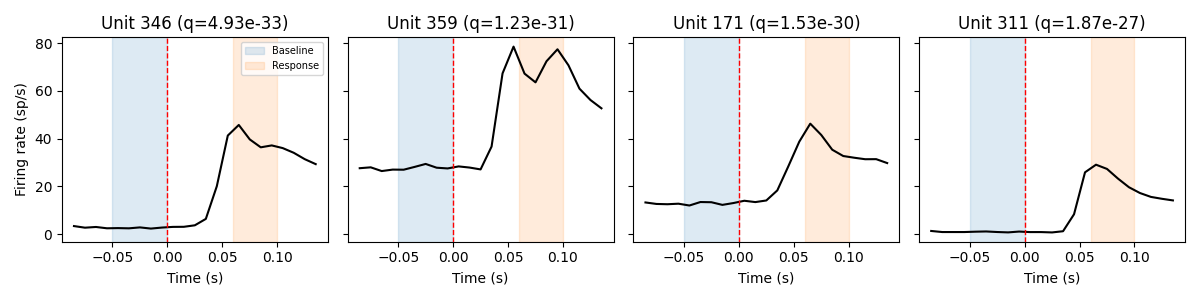

In [6]:
# Example PSTHs for top selective units
if masks["selective"].any():
    top_units = results_df[results_df["selective"]].sort_values("q").head(4)
    n_plot = len(top_units)
    fig, axes = plt.subplots(1, n_plot, figsize=(3 * n_plot, 3), sharey=True)
    if n_plot == 1:
        axes = [axes]

    for ax, (idx, row) in zip(axes, top_units.iterrows()):
        uid = int(row["unit"])
        mean_psth = peth[idx].mean(axis=0)  # idx is positional (0-based)
        ax.plot(bin_centers, mean_psth, color="black")
        ax.axvspan(-0.05, 0.0, color="tab:blue", alpha=0.15, label="Baseline")
        ax.axvspan(0.06, 0.10, color="tab:orange", alpha=0.15, label="Response")
        ax.axvline(0, color="red", linestyle="--", linewidth=1)
        ax.set(
            xlabel="Time (s)",
            title=f"Unit {uid} (q={row['q']:.2e})",
        )
    axes[0].set_ylabel("Firing rate (sp/s)")
    axes[0].legend(loc="best", fontsize=7)
    plt.tight_layout()
else:
    print("No selective units found.")